# CO₂ pressurization — a worked `tea` case

Three-stage compression with intercooling to 308 K, assessed end to end:
case setup, flowsheet import, cost estimation, pinch analysis, heat exchanger
network synthesis and discounted cash flow.

**This notebook is evidence, not a tutorial.** It is not executable outside its
original environment — the `tea` package is pre-release and not distributed
here, and the flowsheet import requires a local DWSIM file. The cell outputs are
stored, so what the package produces is visible without running anything.

Basis: EUR, reference year 2026, CEPCI, Germany, gate-to-gate,
90 % annual availability, interest rate 20 %, tax rate 30 %,
10 a production phase.

## 1 · Case setup

Goal, scope and inventory are structural elements of the case object, not
documentation alongside it. Every assumption below is addressable, persisted
and reproducible.

In [ ]:
## Import required modules, types and units
from tea import TEA                                                                    # Top-level tea class

# Imports required to set up a new case
# ------------------------------------------------------------------------------------------------------------
# Types and units sets provide guidance with respect to appropriate parameters and values
# ------------------------------------------------------------------------------------------------------------
import tea.utilities.types as tps                                                      # Guidance for proper parameter selection during case setup
import tea.units as u                                                                  # pint-backed unit and currency system
import tea.models as tea_mods                                                          # Case-level model objects (utilities, estimators, scenarios, ...)

In [ ]:
# Case ID
project = "co2_pressurization"
process_slug = "three_stage_intercooling_308_kelvin"
scenario = "base"

# Create new case (skeleton case already available)
"""
t = TEA.new(
    project=project,
    process_name="CO2 pressurization using multistage compression with intercooling",
    process_slug=process_slug,
    tea_type=tps.TEAType.BROWNFIELD,
    scenario=scenario,
)
""";

# Load existing case
t = TEA.load(
    project=project,
    process_slug=process_slug,
    scenario=scenario,
)

In [ ]:
goal = t.goal
goal.context = "Assessment of economic viability of multi-stage CO2 compression with intercooling to ambient temperature under various cost regimes"
goal.target_audience.add("INTERNAL: Business development lead / CTO")
goal.study_limitations.add("Preliminary, pending approval and second iteration.")
goal.intended_application.add("Support case parametrization for a grant application")
goal.authors.add("R&D: process simulation; Controlling: prices and business case")
goal.commissioners.add("INTERNAL")
goal.overall_trl = 9
# goal.show()

In [ ]:
## Scope definition
scope = t.scope
scope.functional_unit = u.matter_flow.kt_per_a
scope.system_boundary = tps.SystemBoundaryType.GATE_TO_GATE

# Path to the DWSIM flowsheet of this case (local path in the original run)
scope.flowsheet_simulation_file = r"flowsheets/co2_pressurization_intercool308K_flash.dwxmz"

# Define >= 1 system element(s) and add it to the case
co2_pressurization = tea_mods.SystemElement(
    name="CO2-pressurization",
    trl=9
)
scope.system_elements.add(co2_pressurization)
# scope.show()

In [ ]:
# Definition of basic technical and economic case assumptions
context = t.inventory.context
context.case_currency = u.currency.EUR
context.cost_index = tps.CostIndex.CEPCI
context.plant_type = tps.PlantType.FLUID
context.reference_year = 2026
context.geographic_context = "Well-developed country, skilled labor, excellent site infrastructure, highly regulated, high energy cost"
context.location = "Germany"
# context.show()

In [ ]:
# Basic process conditions assumptions
inv_pc = t.inventory.process_conditions
inv_pc.annual_plant_availability_value=0.9
inv_pc.annual_plant_availability_unit=u.TIMEFRAC

In [ ]:
# Basic economic assumptions
inv_econ = t.inventory.economic_evaluation
inv_econ.interest_rate=u.CurrencyFrac(0.2)
inv_econ.tax_rate=u.CurrencyFrac(0.3)
inv_econ.investment_phase=1
inv_econ.production_phase=10
inv_econ.production_schedule_type=tps.ProductionScheduleType.LINEAR_ONRAMP
inv_econ.startup_period=3

In [ ]:
# Basic heat integration assumptions
inv_hi = t.inventory.heat_integration
inv_hi.dT_min_value = 10
inv_hi.dT_min_unit = u.temperature.K

In [1]:
# Define applied utility set for the case
from tea.units.compound_units import specific_heat_capacity_p

# Set readthrough and add utllities
inv_util = t.inventory.utilities

# Define case utilities
cw = tea_mods.Utility(
    type=tps.UtilityType.CW,
    label="Cooling water",
    cp_value=4.19,
    temp_in_value=20,
    temp_out_value=25,
    cost_value=0.025,
    cost_unit=u.matter_price.EUR_per_t
)

el = tea_mods.Utility(
    type=tps.UtilityType.EL,
    label="Grid electricity",
    cost_value=25,
    cost_unit=u.energy_price.EUR_per_MWh
)    

lp = tea_mods.Utility(
    type=tps.UtilityType.LP_STEAM,
    label="LP Steam",
    temp_s_value=130,                         
    dhlv_value=2200,                          
    p_s_value=5,
    cost_value=80,    
    cost_unit=u.matter_price.EUR_per_t,
)

mp = tea_mods.Utility(
    type=tps.UtilityType.MP_STEAM,
    label="MP Steam",
    temp_s_value=180,                         
    dhlv_value=1900,                         
    p_s_value=20,
    cost_value=85,    
    cost_unit=u.matter_price.EUR_per_t,
)

hp = tea_mods.Utility(
    type=tps.UtilityType.HP_STEAM,
    label="HP Steam",
    temp_s_value=250,                         
    dhlv_value=1600,                          
    p_s_value=40,
    cost_value=90,    
    cost_unit=u.matter_price.EUR_per_t,
)

# Add utilities to case
inv_util.add(cw)
inv_util.add(lp)
inv_util.add(mp)
inv_util.add(hp)
inv_util.add(el)

# Inspect included case utilities
inv_util.show()

### TEA inventory: Included utilities

---

ID,Label,Type,Function,Heat type,Cost,T in,T out,T sat,cp,dhlv,p_s
1,Cooling water,cw,cooling,sensible,0.025 EUR/t,20 °C,25 °C,—,4.19 kJ/(kg·K),—,—
2,LP Steam,lp_steam,heating,latent,80 EUR/t,—,—,130 °C,—,2200 kJ/kg,5 bar
3,MP Steam,mp_steam,heating,latent,85 EUR/t,—,—,180 °C,—,1900 kJ/kg,20 bar
4,HP Steam,hp_steam,heating,latent,90 EUR/t,—,—,250 °C,—,1600 kJ/kg,40 bar
5,Grid electricity,el,power,none,25 EUR/MWh,—,—,—,—,—,—


In [2]:
# Inspect inventory status
t.inventory.show()

### TEA inventory: Overview

---

Inventory element,Type,Status
General study context,Sub-Container,5 items
Cost estimation parameters,Sub-Container + Collection,"1 scalar items, 0 CAPEX extra items"
Economic evaluation parameters,Sub-Container,14 scalar items
Basic process assumptions,Sub-Container,2 items
Miscellaneous hints and references,Collection,0 items
Process streams defined,Collection,0 items
Utilities defined,Collection,5 items
Pieces of equipment defined,Collection,0 items
Applied software,Collection,0 items
Applied physical models and methods,Collection,0 items


## 2 · Flowsheet import

Streams, unit operations and the compound set are read from the DWSIM
flowsheet. Writing parameters back and re-solving is a separate path, used by the
sensitivity sweep in section 8.

In [3]:
# Establish bridge to flowsheet simulator
bridge = t.simulation.dwsim.connect()                # t.simulation.aspen.connect() not yet realized

### Connection summary

---

Level,Code,Context,Description
INFO,SIM_WORKING_COPY_ORPHAN_REMOVED,[bridge],Orphaned working copy from an earlier session removed: [project]\flowsheets\_tea_working_copies\co2_pressurization_intercool308K_flash__44256-e997345d.dwxmz
INFO,SIM_WORKING_COPY_CREATED,[bridge],Working copy created; the original is never written to. Source: [project]\flowsheets\co2_pressurization_intercool308K_flash.dwxmz. Copy: [project]\flowsheets\_tea_working_copies\co2_pressurization_intercool308K_flash__20420-8f47c13c.dwxmz


In [4]:
# Import flowsheet component set
t.simulation.import_components(bridge)

### Component import summary

---

#### Runtime information

---

Level,Code,Context,Description
INFO,SIM_IMPORT_COMPLETED,[import],Mode 'merge-only': the run completed. merge-only adds missing components and never overwrites.
INFO,SIM_BRIDGE_STATUS,[import],"The bridge is open: the run ended with close_on_completion=False, or the call has no such parameter. Close it via simulation.close(bridge)."
INFO,SIM_COMPONENTS_IMPORTED,"Carbon dioxide, Water",2 component(s) taken from the flowsheet compound list (sim=True).


#### Skipped items (No results available)

---

No items skipped.


RunReport(3 warning(s), 0 skipped)

In [5]:
t.simulation.import_flowsheet(
    bridge,
    system_element="CO2-pressurization",
    default_material=tps.Material.SS316,
    close_on_completion=False
)

### Flowsheet import summary

---

#### Runtime information

---

Level,Code,Context,Description
INFO,SIM_IMPORT_COMPLETED,[import],Mode 'merge': the run completed. merge adds items and leaves existing ones untouched.
INFO,SIM_BRIDGE_STATUS,[import],"The bridge is open: the run ended with close_on_completion=False, or the call has no such parameter. Close it via simulation.close(bridge)."
INFO,SIM_UNIT_OPERATIONS_IMPORTED,"B-1, C-2, B-3, C-1, C-3, B-2","6 equipment item(s) imported. Defaults: materials='SS316', cost_method='correlation'; vessels additionally the extractor choices orientation/subtype/p_design. Changeable individually via equipment_items.modify/specify."
WARNING,SIM_POWER_UTILITY_NOT_WIRED,"C-2, C-1, C-3","power_utility not wired: 3 compressor(s) without utility_refs (bucket-2 OPEX stays empty, §8.3). To retrofit: create a utility (utility_function=POWER), then per item utility_refs.add(utility_id, specs_field='power')."


#### Skipped items (No results available)

---

No items skipped.


RunReport(4 warning(s), 0 skipped)

In [ ]:
# Import post-processing
inv_eq = t.inventory.equipment_items

# Utility reference used to assign an electricity utility to the compressors
from tea.equipment.models import UtilityRef
electricity_ref = UtilityRef(
    utility_id = 5,
    specs_field = "power"
)
# Assign the utility reference to the compressors
for tag in ("C-1", "C-2", "C-3"):
    inv_eq(tag).utility_refs.add(electricity_ref)

# Specify the TEA-relevant parameters for the cost estimation of the pressure vessels
for tag in ("B-1", "B-2", "B-3"):
    inv_eq.modify(tag, "sizing_input.rho_material", 7980.0)   # Assumed steel density at 25 degC
    inv_eq.modify(tag, "sizing_input.allowable_stress", 1172) # Assumed allowable stress S for SS316 at approx. 310 degC

In [6]:
# Inspect imported component set
t.scope.components.show()

# Inspect imported stream properties
streams=t.inventory.streams
streams.show()
streams.show(section="costs")
streams.show(section="thermal")
streams.show(section="transport")

# Inspect imported unit ops
t.inventory.equipment_items.show(breakdown=True)

### Component inventory

---

Name,Alias,CAS,Molar mass [g/mol],Included in simulation
Carbon dioxide,CO2,124-38-9,44.009500,True
Water,H2O,7732-18-5,18.015280,True


### Stream inventory

---

...

---

,Mass,Volume,Length,Diameter,Wall thickness,Pressure,Temperature,Materials,Correlation ids,Orientation,P design,Rho material,Allowable stress
Tag,kg,m³,m,m,m,bar,°C,,,,bar,kg / m³,bar
B-1,—,—,—,—,—,—,—,{'material': 'SS316'},—,vertical,1.27,"7,980.00",1172
B-3,—,—,—,—,—,—,—,{'material': 'SS316'},—,vertical,50.00,"7,980.00",1172
B-2,—,—,—,—,—,—,—,{'material': 'SS316'},—,vertical,1.58,"7,980.00",1172


#### Compressors

---

,Power,Volume flow in,Pressure in,Pressure out,Temperature in,Temperature out,Materials,Num stages,Polytropic efficiency,Isentropic efficiency,Correlation ids
Tag,kW,m³ / h,bar,bar,°C,°C,,,,,
C-2,52.95,"5,023.62",1.27,1.58,35.00,—,{'material': 'SS316'},1,0.7692,0.7635,—
C-1,49.09,"6,149.17",1.01,1.27,25.00,—,{'material': 'SS316'},1,0.8114,0.8067,—
C-3,"1,281.82","3,980.76",1.58,50.00,35.00,—,{'material': 'SS316'},1,0.7611,0.6855,—


In [7]:
t.inventory.utilities.show()

### TEA inventory: Included utilities

---

ID,Label,Type,Function,Heat type,Cost,T in,T out,T sat,cp,dhlv,p_s
1,Cooling water,cw,cooling,sensible,0.025 EUR/t,20 °C,25 °C,—,4.19 kJ/(kg·K),—,—
2,LP Steam,lp_steam,heating,latent,80 EUR/t,—,—,130 °C,—,2200 kJ/kg,5 bar
3,MP Steam,mp_steam,heating,latent,85 EUR/t,—,—,180 °C,—,1900 kJ/kg,20 bar
4,HP Steam,hp_steam,heating,latent,90 EUR/t,—,—,250 °C,—,1600 kJ/kg,40 bar
5,Grid electricity,el,power,none,25 EUR/MWh,—,—,—,—,—,—


## 3 · Estimators

CAPEX, OPEX and profitability estimators are registered on the case. Several
can coexist; results are then produced per combination, which is what makes a
comparison across cases meaningful.

In [ ]:
# Specify the CAPEX estimator
inv_cost = t.inventory.cost_estimation

# Define working capital method
inv_cost.wc_method = tps.WCMethod.FIXED
inv_cost.wc_fixed_value_currency = u.currency.EUR
inv_cost.wc_fixed_value = 0   # No revenue side in this case, so no working capital is estimated
inv_cost.fdel_default = 0.1

# Specify and add CAPEX estimator
est_FLang = tea_mods.CapexEstimator (
    slug="flang2003",
    label="Lumped Lang-Factor (2003 version)",
    method=tps.CAPEXMethod.FACTORIAL,
    variant="LangRefined2003"
)
inv_cost.capex_estimators.add(est_FLang)

In [ ]:
# Specify OPEX estimator
est_ptw = tea_mods.OpexEstimator (
    slug="ptw_opex",
    label="P/T/W-Opex",
    variant="PTW2003"
)
inv_cost.opex_estimators.add(est_ptw)

In [ ]:
# Specify profitability estimator
inv_econ = t.inventory.economic_evaluation
est_profit = tea_mods.ProfitabilityEstimator (
    slug="npv_irr",
    label="NPV/IRR",
    method=tps.PROFITABILITYMethod.NPV_IRR,
)
inv_econ.profitability_estimators.add(est_profit)

In [8]:
inv_econ.show()

### TEA inventory: Economic evaluation parameters

---

#### Lifecycle phases

---

Parameter,Value
Planning & engineering phase (years),0.00
Investment phase (years),1.00
Production phase (years),10.00
Startup year (0-based index),—
"Startup period (LINEAR_ONRAMP, years)",3.00


...

Parameter,Value
Include terminal value,No
Terminal growth rate,0.00
Compute terminal book value,No


#### Inventory items (count)

---

Collection,Count
Investment extras defined,0
Recovery extras defined,0
Profitability estimators defined,1


*Use inventory.economic_evaluation.investment_extras.show(), .recovery_extras.show() or .profitability_estimators.show() for item details.*


## 4 · Heat integration scenarios

One pinch scenario defines the stream and utility selection and ΔT_min. Several
HEN scenarios are synthesised against it and compared afterwards.

In [9]:
# Pinch scenario: stream and utility selection, minimum approach temperature
pinch_scenario_1 = tea_mods.PinchScenario (
    slug="pinch_scenario_1",
    label="Pinch-Scenario (Base)",
    dT_min_value=10,
    stream_ids=(5,16,17,22,25),
    utility_ids=(1,2,3,4)
)
inv_hi.pinch_scenarios.add(pinch_scenario_1)

# HEN scenarios: four network syntheses against the same pinch scenario,
# varied over EMAT and the admission of intermediate utilities
hen_minlp_ap_1 = tea_mods.HENScenario (
    slug="hen_scenario_1",
    pinch_scenario_slug="pinch_scenario_1",
    label="EMEAT-1",
    synthesis_method=tps.SynthesisMethod.MINLP_AP,
    max_branches_per_stream=3,
    min_branch_fraction=1/3,
    mer_relaxation=1,
    emat_value=1,
    solver_options={"patience": 30},
)
hen_minlp_ap_2 = tea_mods.HENScenario (
    slug="hen_scenario_2",
    pinch_scenario_slug="pinch_scenario_1",
    label="EMEAT-1-IU",
    synthesis_method=tps.SynthesisMethod.MINLP_AP,
    max_branches_per_stream=3,
    min_branch_fraction=1/3,
    mer_relaxation=1,
    emat_value=1,
    allow_intermediate_utilities=True,
    solver_options={"patience": 30},
)
hen_minlp_ap_3 = tea_mods.HENScenario (
    slug="hen_scenario_3",
    pinch_scenario_slug="pinch_scenario_1",
    label="EMEAT-5-IU",
    synthesis_method=tps.SynthesisMethod.MINLP_AP,
    max_branches_per_stream=3,
    min_branch_fraction=1/3,
    mer_relaxation=1,
    emat_value=5,
    allow_intermediate_utilities=True,
    solver_options={"patience": 30},
)
hen_minlp_ap_4 = tea_mods.HENScenario (
    slug="hen_scenario_4",
    pinch_scenario_slug="pinch_scenario_1",
    label="EMEAT-10-IU",
    synthesis_method=tps.SynthesisMethod.MINLP_AP,
    max_branches_per_stream=3,
    min_branch_fraction=1/3,
    mer_relaxation=1,
    emat_value=10,
    allow_intermediate_utilities=True,
    solver_options={"patience": 30},
)

inv_hi.hen_scenarios.add(hen_minlp_ap_1)
inv_hi.hen_scenarios.add(hen_minlp_ap_2)
inv_hi.hen_scenarios.add(hen_minlp_ap_3)
inv_hi.hen_scenarios.add(hen_minlp_ap_4)

# Inspect the input data for the pinch / HEN analysis
inv_hi.show()

### TEA inventory: Heat integration

---

Heat integration parameter,Value
Minimum T approach (value),10.00
Minimum T approach (unit),K
Active HEN slugs,—
Base HX subtype,st_floating_head
Base HX material,CS/CS
Base HX correlation ids,—
Base HX film coefficients,—
Pinch scenarios defined,1 items
HEN scenarios defined,4 items
Heat-integration pool (derived),5 streams


## 5 · Validate and update

`validate()` checks the case for completeness before anything is computed.
`update()` then runs the whole pipeline — equipment sizing, cost estimation,
pinch targeting, HEN synthesis, discounted cash flow — and returns a structured
run report instead of computing silently.

In [10]:
t.validate()

Level,Code,Context,Description
WARNING,SIZING_RESULT_MISSING,Equipment 'B-1',"sizing_method='souders_brown' gesetzt, aber kein Eintrag in tea.results.equipment_sizing['B-1']. tea.update() berechnet das Result in Phase 1; falls bereits gelaufen, pruefe sizing_input oder die vorherige WARNING SIZING_RUNTIME_ERROR."
WARNING,SIZING_RESULT_MISSING,Equipment 'C-2',"sizing_method='direct_spec' gesetzt, aber kein Eintrag in tea.results.equipment_sizing['C-2']. tea.update() berechnet das Result in Phase 1; falls bereits gelaufen, pruefe sizing_input oder die vorherige WARNING SIZING_RUNTIME_ERROR."
WARNING,SIZING_RESULT_MISSING,Equipment 'B-3',"sizing_method='souders_brown' gesetzt, aber kein Eintrag in tea.results.equipment_sizing['B-3']. tea.update() berechnet das Result in Phase 1; falls bereits gelaufen, pruefe sizing_input oder die vorherige WARNING SIZING_RUNTIME_ERROR."
WARNING,SIZING_RESULT_MISSING,Equipment 'C-1',"sizing_method='direct_spec' gesetzt, aber kein Eintrag in tea.results.equipment_sizing['C-1']. tea.update() berechnet das Result in Phase 1; falls bereits gelaufen, pruefe sizing_input oder die vorherige WARNING SIZING_RUNTIME_ERROR."
WARNING,SIZING_RESULT_MISSING,Equipment 'C-3',"sizing_method='direct_spec' gesetzt, aber kein Eintrag in tea.results.equipment_sizing['C-3']. tea.update() berechnet das Result in Phase 1; falls bereits gelaufen, pruefe sizing_input oder die vorherige WARNING SIZING_RUNTIME_ERROR."
WARNING,SIZING_RESULT_MISSING,Equipment 'B-2',"sizing_method='souders_brown' gesetzt, aber kein Eintrag in tea.results.equipment_sizing['B-2']. tea.update() berechnet das Result in Phase 1; falls bereits gelaufen, pruefe sizing_input oder die vorherige WARNING SIZING_RUNTIME_ERROR."
WARNING,EMPTY_CAPEX_EXTRAS,Inventar,"inventory.cost_estimation.capex_extras ist leer, obwohl Equipment-Items mit cost_method vorhanden sind. Typischerweise enthaelt ein vollstaendiger CAPEX-Scope Posten wie LAND, STARTUP oder CATALYST_CHARGE. Vgl. tea_v60 Abschnitt 5.4.1."
WARNING,STALE_EQUIPMENT_COST,Equipment 'B-1',Equipment-Kostenergebnis fehlt. tea.equipment.costs.estimate('B-1') oder tea.update() aufrufen.
WARNING,STALE_EQUIPMENT_COST,Equipment 'C-2',Equipment-Kostenergebnis fehlt. tea.equipment.costs.estimate('C-2') oder tea.update() aufrufen.
WARNING,STALE_EQUIPMENT_COST,Equipment 'B-3',Equipment-Kostenergebnis fehlt. tea.equipment.costs.estimate('B-3') oder tea.update() aufrufen.


ValidationResult(0 ERROR(s), 14 WARNING(s))

In [11]:
# One call: equipment sizing, cost estimation, pinch targeting,
# HEN synthesis and discounted cash flow
t.update(hen_mode="auto_cheapest")

### Update report

---

#### Runtime information

---

Level,Code,Context,Description
INFO,HEAT_INTEGRATION_AUTO_BASE_GENERATED,Heat integration,"5 Auto-Base-HX erzeugt (Material CS/CS, Subtyp st_floating_head); ueberschreibbar via inventory.heat_integration.base_hx_*."
INFO,HEN_MINLP_AUDIT,HENScenario 'hen_scenario_1',"AP Step 1 (relaxierter NLP): y0_integral=False, viol=3.508e-10, tac=1.52352e+06."
INFO,HEN_MINLP_AUDIT,HENScenario 'hen_scenario_1',"AP Patience: Incumbent seit 30 feasiblen NLPs ohne Verbesserung -> Stop, bester Incumbent zurueck."
INFO,HEN_MINLP_AUDIT,HENScenario 'hen_scenario_2',"AP Step 1 (relaxierter NLP): y0_integral=False, viol=3.467e-10, tac=1.49824e+06."
INFO,HEN_MINLP_AUDIT,HENScenario 'hen_scenario_4',"AP Step 1 (relaxierter NLP): y0_integral=False, viol=3.499e-10, tac=1.49534e+06."
INFO,HEN_MINLP_AUDIT,HENScenario 'hen_scenario_4',"AP Patience: Incumbent seit 30 feasiblen NLPs ohne Verbesserung -> Stop, bester Incumbent zurueck."
INFO,HEN_AUTO_CHEAPEST_RANKING,hen_mode=auto_cheapest,"auto_cheapest Per-Pinch-Δ-Zerlegung der Selektion (§7.3.3 Selektions-Metrik; aufsteigend nach Δ, groesste Ersparnis zuerst): Pinch 'pinch_scenario_1' -> h*=hen_scenario_1, Ersparnis -Δ=2.4576e+06 (in K). Gewinner-Kombination K=['hen_scenario_1'], whole_pool_tac(K)=1.52142e+06 gegen Pure-Base (base_tac)=3.97902e+06. Pre-Screening-Indikator (nicht die volle Plant-/Profitabilitaets-Bewertung); gescheiterte Kandidaten erscheinen nicht in der Zerlegung, sondern tragen HEN_SYNTHESIS_INFEASIBLE/HEN_REALIZATION_FAILED. Die stehende, modus-unabhaengige Form derselben Whole-Pool-Metrik sind die persistierten Pool-Records (results.pool) — geteilter Rechenkern; die Per-Pinch-Δ-Zerlegung entspricht den {hen_slug}-Records gegen 'base'. (Abschnitte 7.3.3, 10.4.10)"
INFO,HEN_AUTO_CHEAPEST_SELECTED,hen_mode=auto_cheapest,"auto_cheapest hat die strom-disjunkte Kombination K=['hen_scenario_1'] fuer diesen Lauf aktiv gesetzt (Lauf-Slot tea.results.hen.active_hen_slugs=['hen_scenario_1'], realisiertes Whole-Pool-Subsystem-TAC whole_pool_tac(K) 1.52142e+06 < Pure-Base 3.97902e+06); kein Inventory-Write, die Wahl wird nicht persistiert. Zum dauerhaften Festsetzen active_hen_slugs=['hen_scenario_1'] setzen und mit hen_mode='keep_active' fahren. (Abschnitt 7.3.3)"
WARNING,EMPTY_CAPEX_EXTRAS,Inventar,"inventory.cost_estimation.capex_extras ist leer, obwohl Equipment-Items mit cost_method vorhanden sind. Typischerweise enthaelt ein vollstaendiger CAPEX-Scope Posten wie LAND, STARTUP oder CATALYST_CHARGE. Vgl. tea_v60 Abschnitt 5.4.1."


#### Skipped items (No results available)

---

Level,Code,Context,Description
WARNING,PROFITABILITY_DEGENERATE_INPUT,Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -9.765333e+07 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."


RunReport(9 warning(s), 1 skipped)

## 6 · Results

Every result object renders itself. `breakdown=True` shows the full line-item
decomposition with the applied factors, so a number can be traced back to its
basis.

In [12]:
t.results.capex.show(slug="flang2003", breakdown=True)

### CAPEX result: Lumped Lang-Factor (2003 version)

---

#### Headline

---

#,Estimator label,Method,Variant,PEC Basis,Specified factor overrides,FCI (est.),FCI (tot.),TPI,TCI
1,Lumped Lang-Factor (2003 version),factorial,LangRefined2003,5.70,—,28.51,28.51,28.51,28.51


...

---

Parameter,Value
label,Lumped Lang-Factor (2003 version)
slug,flang2003
method,factorial
variant,LangRefined2003
user_notes,—


#### Calculation parameters

---

Parameter,Value
Reference year,2026
Case currency,EUR
Plant type,fluid
Cost index,CEPCI
Fdel default,0.10
Location factor,—
Working capital method,fixed
Working capital input,0.00
Calculated date,2026-09-04
Calculated time,03:33:06


In [13]:
t.results.equipment_costs.show(breakdown=True)

### Equipment cost overview (plant)

---

,CAPEX,OPEX,TAC
Equipment type,M EUR,M EUR/a,M EUR/a
Heat exchangers,0.39,1.43,1.52
Pressure vessels,0.23,—,0.06
Compressors,5.08,0.27,1.48
Total,5.70,1.70,3.06


Reference year 2026. TAC = CRF·CAPEX + OPEX.
CAPEX = sum of equipment cost after redundancy for each inventory item (if applicable: escalated, delivered, materialized, converted to case currency).
OPEX  = sum of annual utility-driven operational cost for each inventory item (Bucket 2 — derived from utility_refs).
All results are up to date.


#### Heat exchangers

...

---

Reference year 2026. TAC = CRF·CAPEX + OPEX.


#### Calculation parameters

---

Parameter,Value
Case currency,EUR
Plant type,fluid
Reference year,2026
Annual availability,"7,884 h/a"


In [14]:
t.results.opex.show(combo_slug="flang2003__ptw_opex", breakdown=True)

### OPEX result: Lumped Lang-Factor (2003 version) × P/T/W-Opex

---

#### Headline

---

#,CAPEX label,OPEX label,Variant,Variable OPEX,Fixed OPEX,Other,Credits,Total OPEX
1,Lumped Lang-Factor (2003 version),P/T/W-Opex,PTW2003,1.70,5.38,0.00,0.00,7.08


...

---

Parameter,Value
CAPEX label,Lumped Lang-Factor (2003 version)
CAPEX slug,flang2003
OPEX label,P/T/W-Opex
OPEX slug,ptw_opex
OPEX variant,PTW2003
User notes,—


#### Calculation parameters

---

Parameter,Value
Reference year,2026
Case currency,EUR
Plant type,fluid
Cost index,CEPCI
Location factor,—
Shift positions,—
Operator annual salary,—
Shift factor,5.00
Calculated date,2026-09-04
Calculated time,03:33:06


In [15]:
t.results.pinch.show()

### Pinch results overview

---

Scenario,q_hot_min,q_cold_min,t_pinch,N_min,area_target,q_recovery
Pinch-Scenario (Base),1363.3 kW,0.0 kW,Threshold,5,953.9 m²,1672.5 kW
Whole pool (auto),1363.3 kW,0.0 kW,Threshold,5,953.9 m²,1672.5 kW


All results are up to date.


In [16]:
t.results.hen.compare(breakdown=True)

### HEN comparison

---

#### Realization summary

---

Metric,1,2,3,4
Synthesis status,OK,OK,OK,OK
Synthesis method,minlp_ap,minlp_ap,minlp_ap,minlp_ap
Pinch scenario,pinch_scenario_1,pinch_scenario_1,-,pinch_scenario_1
Termination,converged,max_iterations,converged,converged


...

Metric,1,2,3,4
Minimum approach temperature of underlying pinch case,10.0 K,10.0 K,-,10.0 K
EMAT (per-unit minimum approach),1.0 K,1.0 K,-,10.0 K
Superstructure stages (input),"auto (max NH, NC)","auto (max NH, NC)","auto (max NH, NC)","auto (max NH, NC)"
Maximum MER relaxation,1.0,1.0,1.0,1.0
Maximum stream splits (branches/stream),3,3,3,3
Minimum stream split fraction,0.333,0.333,0.333,0.333
No-split streams,-,-,-,-
Forbidden matches,-,-,-,-
Required matches,-,-,-,-
Material override,-,-,-,-


#### Legend

---

#,Scenario label,HEN slug
1,EMEAT-1,hen_scenario_1
2,EMEAT-1-IU,hen_scenario_2
3,EMEAT-5-IU,hen_scenario_3
4,EMEAT-10-IU,hen_scenario_4


All compared results are up to date.


In [17]:
t.results.pool.show()

### Pool results overview

---

Reference year 2026. TAC = CRF·CAPEX + OPEX.
All results are up to date.


In [18]:
t.results.equipment_sizing.show()

### Equipment sizing results

---

#### Heat exchangers

---

ΔT_min:  (case) = 10 K;  EMEAT-1 = 1 K;  EMEAT-1-IU = 1 K;  EMEAT-5-IU = 10 K;  EMEAT-10-IU = 10 K


#### Pressure vessels

---

#### Compressors

---

In [19]:
t.inventory.equipment_items.show(tag="B-2")

### Equipment item: B-2

---

Field,Value
Tag,B-2
Typ,pressure_vessel
Subtyp,vertical
System-Element,CO2-pressurization
Parent,—
Kostenmethode,correlation
Quotes,0


#### Specs

---

Field,Value
mass [kg],—
volume [m³],—
length [m],—
diameter [m],—
wall_thickness [m],—
pressure [bar],—
temperature [°C],—
materials,{'material': 'SS316'}
correlation_ids,—


#### Sizing input

---

Field,Value
orientation,vertical
p_design [bar],1.58
stream_V,20
stream_L,18
stream_F,19
rho_material [kg / m³],"7,980.00"
allowable_stress [bar],1172


In [20]:
t.results.hen.show("hen_scenario_1")

### HEN result — EMEAT-1

---

#### Realization summary

---

Quantity,Value
Synthesis status,OK
Synthesis method,minlp_ap
Pinch scenario,pinch_scenario_1
Termination,converged


...

Quantity,Value
Heat recovered,1652.5 kW
Maximum recoverable (MER target),1672.5 kW
Recovery fraction,0.988
Number of units,6
Total area,711.5 m²
HEN CAPEX,0.39 M EUR
HEN OPEX,1.43 M EUR/a
HEN TAC,1.52 M EUR/a


#### Calculation parameters

---

Parameter,Value
Minimum approach temperature of underlying pinch case,10.0 K
EMAT (per-unit minimum approach),1.0 K
Superstructure stages (input),"auto (max NH, NC)"
Maximum MER relaxation,1.0
Maximum stream splits (branches/stream),3
Minimum stream split fraction,0.333
No-split streams,-
Forbidden matches,-
Required matches,-
Material override,-


*Values shown in M EUR.*


In [21]:
t.results.profitability.show(profitability_result_slug="npv_irr__flang2003__ptw_opex", breakdown=True)

### Profitability result: NPV/IRR

---

#### Headline

---

Estimator label,Method,NPV,IRR,Timestamp
NPV/IRR,npv_irr,-56.87 M EUR,—,2026-09-04T03:33:06.803632


...

Parameter,Value
Estimator label,NPV/IRR
Profitability slug,npv_irr
Combo slug,flang2003__ptw_opex
CAPEX slug,flang2003
OPEX slug,ptw_opex
Method,npv_irr
User notes,—


#### Calculation parameters

---

Parameter,Value
Reference year,2026
Case currency,EUR
Tax rate,30.00 %
Interest rate,20.00 %
Inflation rate,0.00 %
Nominal interest rate,20.00 %
Depreciation method,linear
Depreciation period,10
Startup year,1
Compute terminal book value,False


Values shown in M EUR (reference year 2026).


## 7 · Figures

Each plot recipe has a notebook mode and a report mode. Export at fixed
physical size as PNG, PDF or SVG.

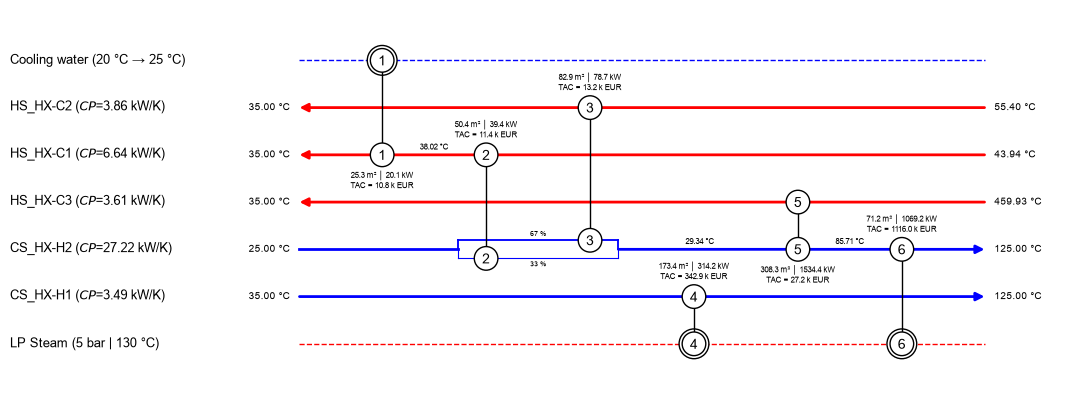

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = t.plots.hen_grid("hen_scenario_1", mode="notebook")
fig

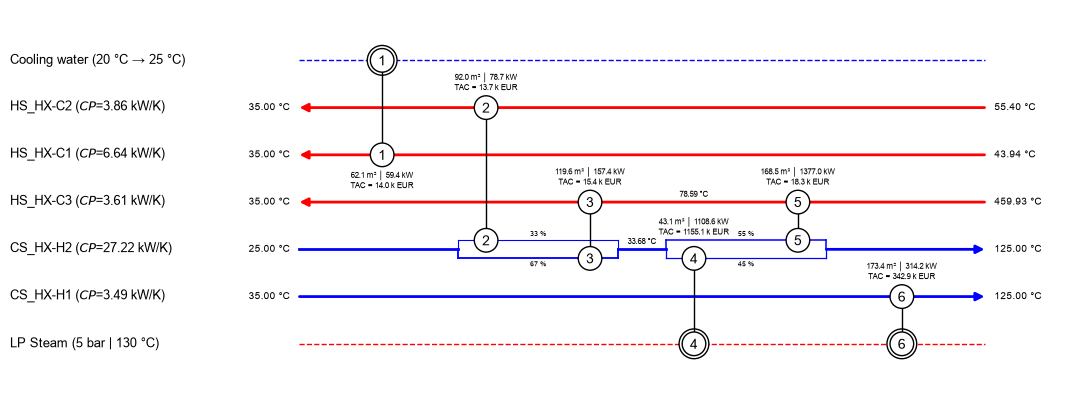

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = t.plots.hen_grid("hen_scenario_2", mode="notebook")
fig

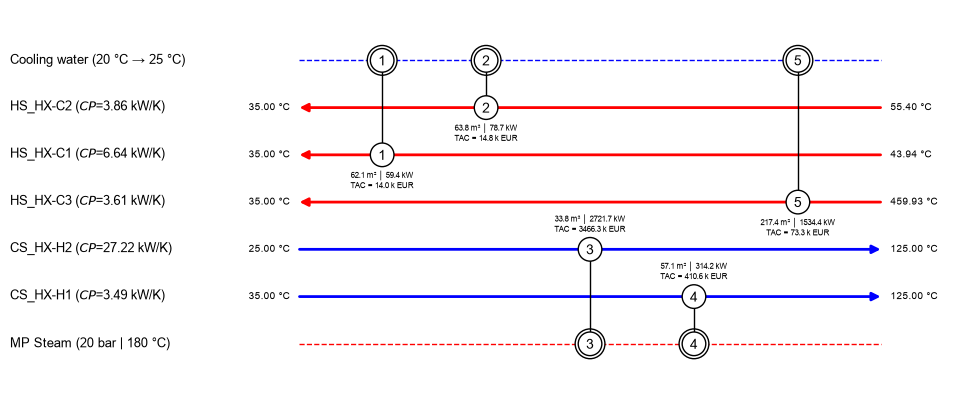

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = t.plots.hen_grid("hen_scenario_3", mode="notebook")
fig

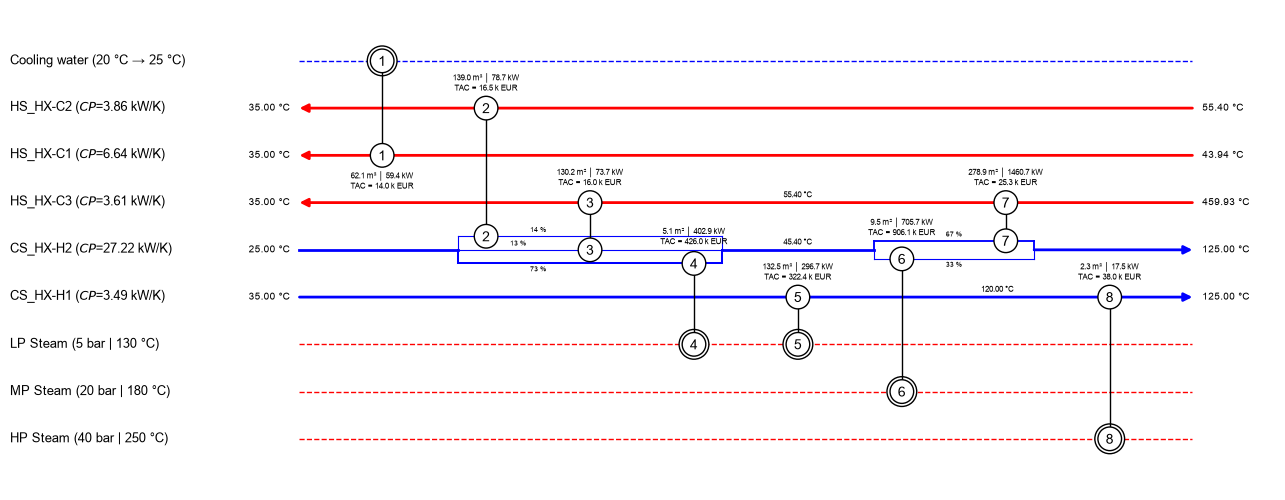

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = t.plots.hen_grid("hen_scenario_4", mode="notebook")
fig

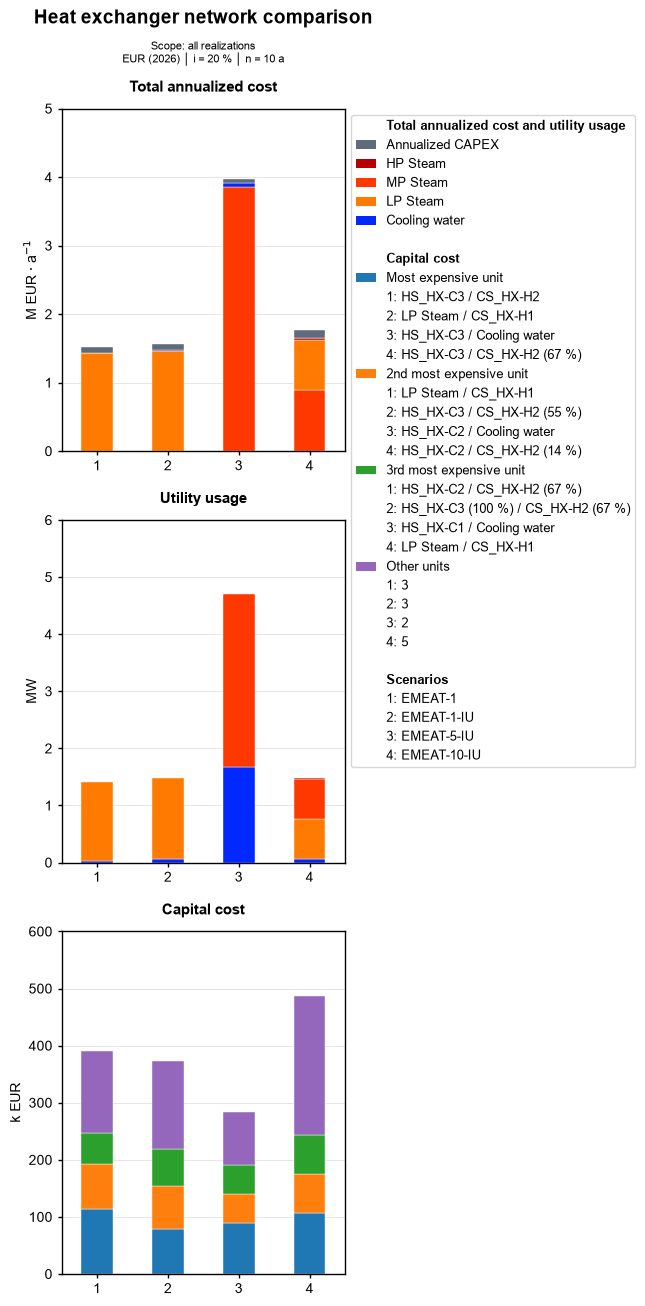

In [26]:
t.plots.hen_compare(breakdown=True, top_k=3)

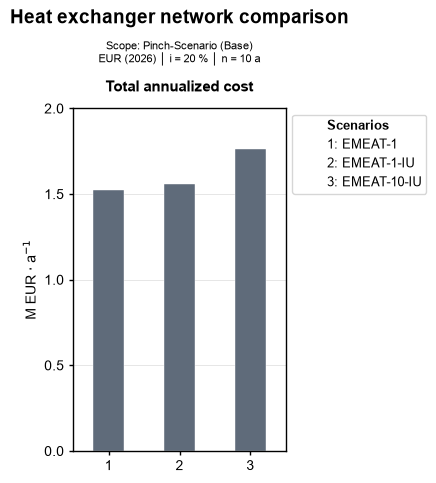

In [27]:
fig=t.plots.hen_compare(pinch_slugs="pinch_scenario_1", layers=["tac"])
#fig.set_dpi(350)
fig

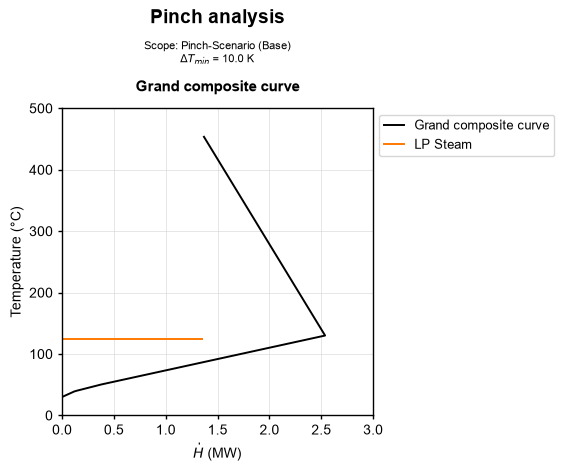

In [28]:
fig1=t.plots.gcc(slug="pinch_scenario_1")
fig1

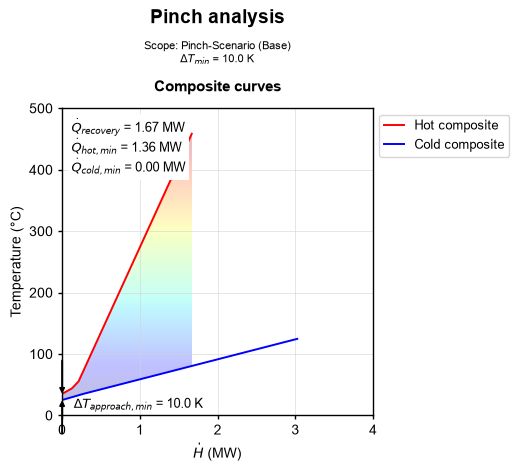

In [29]:
fig=t.plots.composite_curves(slug="pinch_scenario_1")
#fig.set_dpi(150)
fig

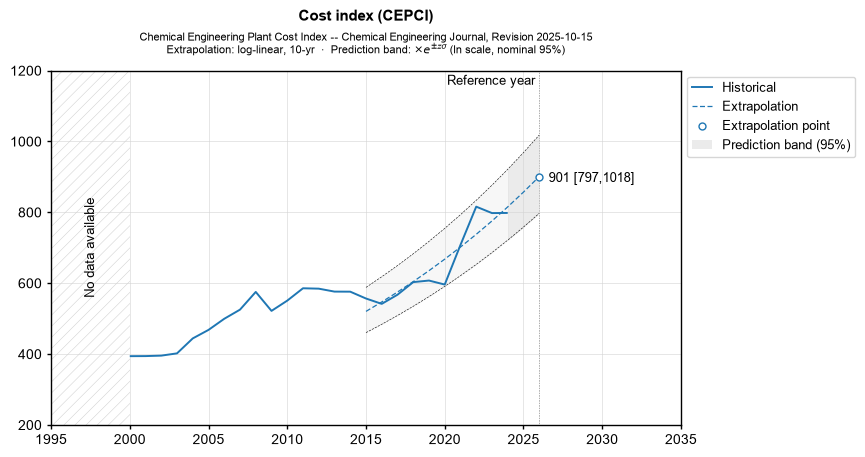

In [30]:
fig_h1=t.plots.index(index_ids="CEPCI")
fig_h1

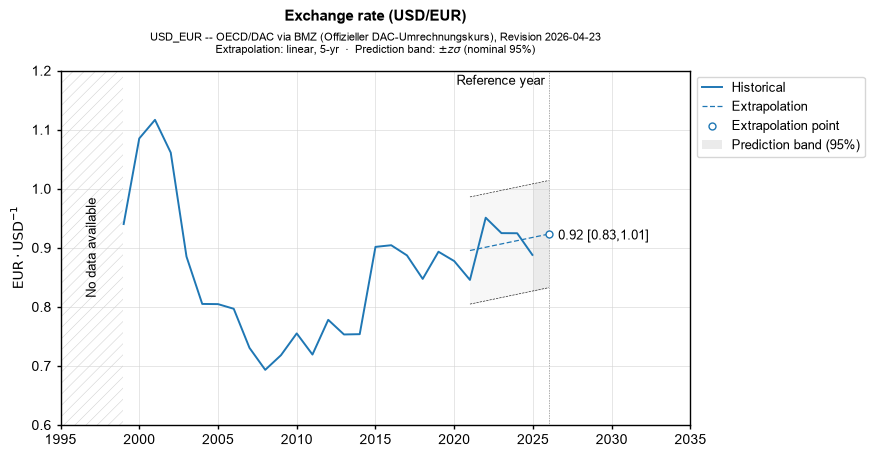

In [31]:
fig_h2=t.plots.currency(pair_id="USD_EUR")
fig_h2

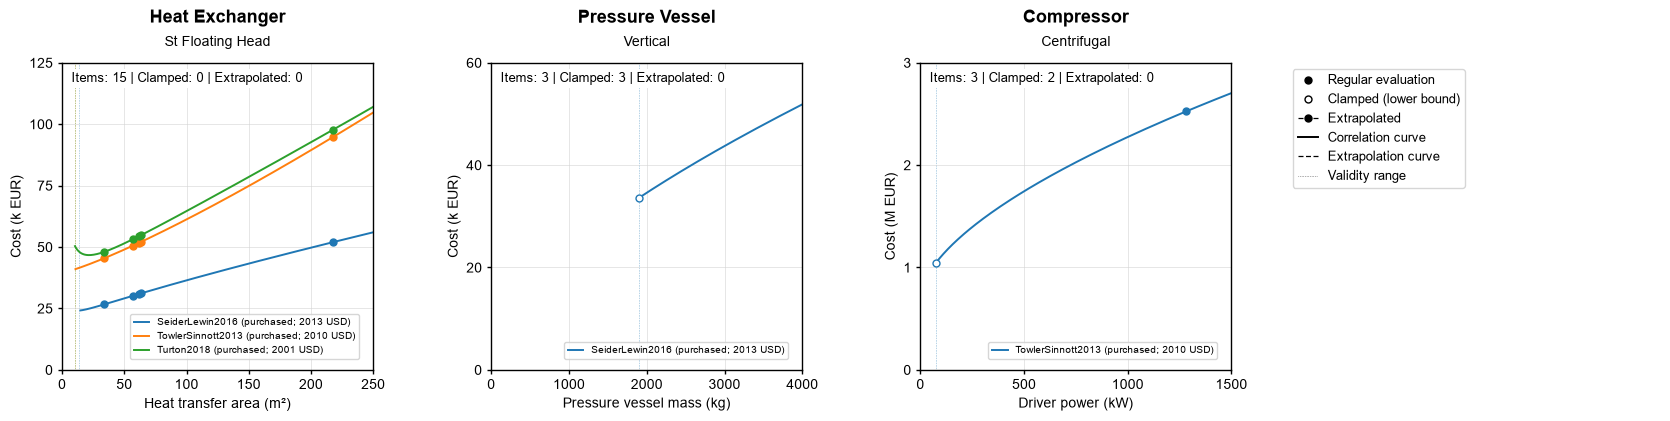

In [32]:
# Check the health status of all correlation evaluations
fig_h2 = t.plots.correlations()
fig_h2

## 8 · Sensitivity analysis

A sensitivity case sweeps flowsheet and TEA parameters over a persisted
scenario and retains the tracked results for comparison. The sweep below spans
the two stage pressure ratios and the LP-steam price, 125 points in total, and
re-runs the full pipeline at every point — flowsheet solve, import, costing,
pinch targeting, network synthesis.

> **Run against an earlier state of the case.** The sweep below was computed
> before a stray compressor and two orphaned streams were removed from the
> flowsheet, so its absolute values do not line up with the results above. It is
> shown for the mechanism; the numbers are superseded.

In [ ]:
from tea.interpretation.models import SensitivityCase, SweepParameters

In [33]:
# --- Sweep axes ---------------------------------------------------------
# Addressable are: streams(<int>).<section>.<field>_value, <container>.<field>,
# utilities(<int>).<field>, equipment_items('<tag>').<field>
# Values are given either as a list [v1, v2, ...] or as {"start", "stop", "n"} (+ "unit")

sweep = SweepParameters(
    tea_parameterset={
        "utilities(2).cost_value": {"start": 30, "stop": 50, "n": 5},        # LP steam price
    },
    flowsheet_parameterset = {
        "flowsheet('C-1').pressure_ratio": {"start": 1.25, "stop": 7, "n": 5},
        "flowsheet('C-2').pressure_ratio": {"start": 1.25, "stop": 7, "n": 5},
    },
)

# --- Case ---------------------------------------------------------------
case = SensitivityCase(
    slug="hi_tracking_probe_3",
    label="HI-Tracking-Probe (pool)",
    description="Heat-integration tracking: HEN metrics and utility pool over the stage pressure ratios",
    sweep_parameters=sweep,
    tracking_results=["hen", "pool", "capex", "opex", "profitability", "utilities"],
    pool_config_key="cheapest",   # which pool record goes into the sidecar: "base", "<hen_slug>", "active", "cheapest"
    hen_mode="auto_cheapest",
    hen_by_pinch_slugs="pinch_scenario_1",
)

t.interpretation.sensitivity_cases.add(case)
result = t.interpretation.run(
    case,
    bridge=bridge,
    backup="skip",
    verbose="progress",
    resume=False,
    close_on_completion=False,
)

### Sensitivity case sweep report — HI-Tracking-Probe (pool)

---

#### Sweep runtime information

---

Level,Code,Context,Description
INFO,SWEEP_TRAVERSAL,[sweep],Calculation of 125 of 125 traversed points completed successfully (100 %).


...

---

Level,Code,Context,Description
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 1] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.050704e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 2] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.059047e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 3] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.061429e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 4] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.080205e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 5] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.086454e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 6] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.105040e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 7] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.090244e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 8] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.119296e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 9] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.070492e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."
WARNING,PROFITABILITY_DEGENERATE_INPUT,[points: 10] Pair 'npv_irr__flang2003__ptw_opex',"Sigma cash_flow_nominal = -1.056632e+08 <= 0 — IRR undefiniert (§8.5.6 Stage 1, Degenerate-Guard)."


#### Sweep-level issues

---

Level,Code,Context,Description
INFO,SIM_FLOWSHEET_RESTORED,[sweep],"Ausgangskoordinate zurueckgeschrieben (2 Ziel(e)), Solve konvergiert."
INFO,SIM_BRIDGE_STATUS,[sweep],"The bridge is open: the run ended with close_on_completion=False, or the call has no such parameter. Close it via simulation.close(bridge)."


The result table of the whole sweep — 125 points over 57 tracked
quantities — is omitted here for file size. A `SensitivityView` selects a
readable slice of it: one tracked quantity, an x axis, a curve family, and the
remaining dimensions held fixed.

### Sweep results — HI-Tracking-Probe (pool)

---

#### Result table

---

1,2,3,4,5,34,57
1.25,1.25,50.00,hen_scenario_2,—,1.01,—
1.25,2.69,50.00,hen_scenario_1,—,1.12,—
1.25,4.12,50.00,hen_scenario_2,—,1.15,—
1.25,5.56,50.00,hen_scenario_2,—,1.23,—
1.25,7.00,50.00,hen_scenario_4,—,1.22,—
2.69,7.00,50.00,hen_scenario_1,—,1.24,—
2.69,5.56,50.00,hen_scenario_2,—,1.43,—
2.69,4.12,50.00,hen_scenario_2,—,1.40,—
2.69,2.69,50.00,hen_scenario_1,—,1.31,—
2.69,1.25,50.00,hen_scenario_1,—,1.12,—


...

Field,Value
case_slug,hi_tracking_probe_3
case_label,HI-Tracking-Probe (pool)
case_type,sensitivity
row_count,125
sidecar_path,simulations/hi_tracking_probe_3.csv
timestamp,2026-09-04 02:23:52


#### Inventory values at run time

---

Field,Value
reference_year,2026
case_currency,EUR
plant_type,fluid
cost_index,CEPCI
location_factor,—
interest_rate,20.00 %
tax_rate,30.00 %
investment_phase,1
production_phase,10
startup_year,—


This result is up to date.
Column numbers above are accepted as input when a SensitivityView is created; the View address column carries the form such a view stores.


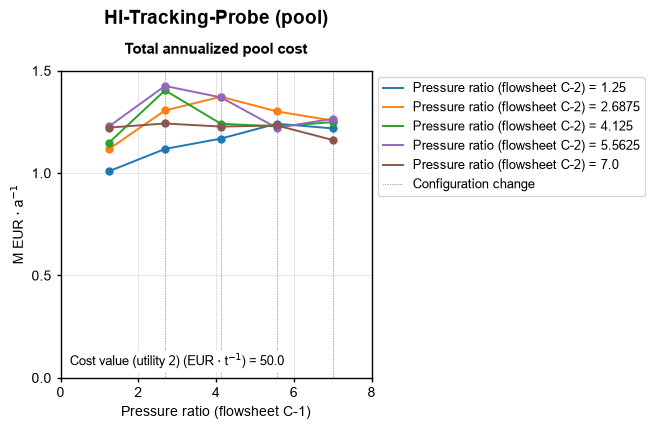

In [34]:
from tea.interpretation import SensitivityView

# A view selects what is plotted: one tracked quantity, an x axis, a curve
# family, and the remaining sweep dimensions held fixed.
t.interpretation.sensitivity_views.add(SensitivityView(
    slug="hi_probe3_schar_2",
    label="Heat-integration pool coverage cost",
    sensitivity_case_slug="hi_tracking_probe_3",
    values=["pool.pool_tac"],
    x="flowsheet('C-1').pressure_ratio",       # 5 support points
    series="flowsheet('C-2').pressure_ratio",  # 5 curves
    select={"utilities(2).cost_value": ["50"]},  # held fixed
))
t.results.interpretation.show("hi_tracking_probe_3", view="hi_probe3_schar_2")
fig = t.plots.sensitivity("hi_tracking_probe_3", view="hi_probe3_schar_2")
fig

### Sweep results — HI-Tracking-Probe (pool)

---

#### Result table

---

1,2,3,4,5,43,57
1.25,1.25,50.00,hen_scenario_2,—,7.57,—
1.25,2.69,50.00,hen_scenario_1,—,7.71,—
1.25,4.12,50.00,hen_scenario_2,—,7.72,—
1.25,5.56,50.00,hen_scenario_2,—,7.88,—
1.25,7.00,50.00,hen_scenario_4,—,7.80,—
2.69,7.00,50.00,hen_scenario_1,—,7.83,—
2.69,5.56,50.00,hen_scenario_2,—,8.32,—
2.69,4.12,50.00,hen_scenario_2,—,7.93,—
2.69,2.69,50.00,hen_scenario_1,—,8.03,—
2.69,1.25,50.00,hen_scenario_1,—,7.64,—


...

Field,Value
case_slug,hi_tracking_probe_3
case_label,HI-Tracking-Probe (pool)
case_type,sensitivity
row_count,125
sidecar_path,simulations/hi_tracking_probe_3.csv
timestamp,2026-09-04 02:23:52


#### Inventory values at run time

---

Field,Value
reference_year,2026
case_currency,EUR
plant_type,fluid
cost_index,CEPCI
location_factor,—
interest_rate,20.00 %
tax_rate,30.00 %
investment_phase,1
production_phase,10
startup_year,—


This result is up to date.
Column numbers above are accepted as input when a SensitivityView is created; the View address column carries the form such a view stores.


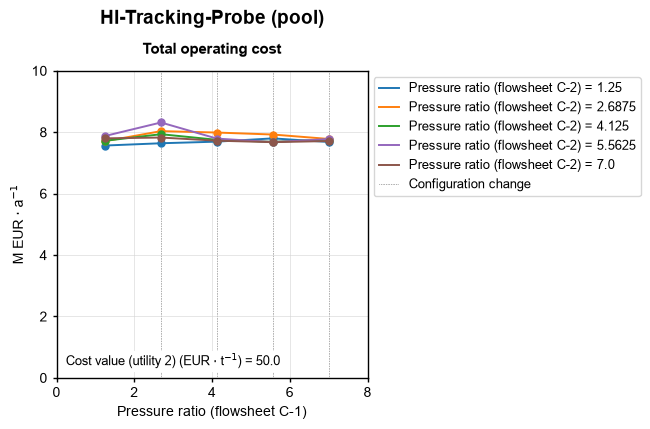

In [35]:
t.interpretation.sensitivity_views.add(SensitivityView(
    slug="hi_probe3_schar_3",
    label="Total operating cost",
    sensitivity_case_slug="hi_tracking_probe_3",
    values=["opex.total_opex_per_year"],
    x="flowsheet('C-1').pressure_ratio",       # 5 support points
    series="flowsheet('C-2').pressure_ratio",  # 5 curves
    select={"utilities(2).cost_value": ["50"]},  # held fixed
))
t.results.interpretation.show("hi_tracking_probe_3", view="hi_probe3_schar_3")
fig = t.plots.sensitivity("hi_tracking_probe_3", view="hi_probe3_schar_3")
fig